In [53]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
import random
from sklearn.datasets import fetch_openml
import os
import struct
from mnist.loader import MNIST
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import time

In [54]:
!pip install python-mnist


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Users\Ashura\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [55]:
mndata = MNIST('MNIST')
images, labels = mndata.load_training()
list_labels = list(labels)
def plot_image_index(list_labels, images, labels, number):
    plt.figure(figsize=(12, 6))
    labels_index = []
    for i in range(number):
        labels_index.append(list_labels.index(i))
        image_2d  = np.array(images[list_labels.index(i)]).reshape(28,28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image_2d, cmap='gray')
        plt.title(f"Index: {i} \nLabel: {labels[list_labels.index(i)]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

def label_index(list_labels):
    labels_index = []
    for i in range(10):
        labels_index.append(list_labels.index(i))
    return labels_index

label_index = label_index(list_labels)

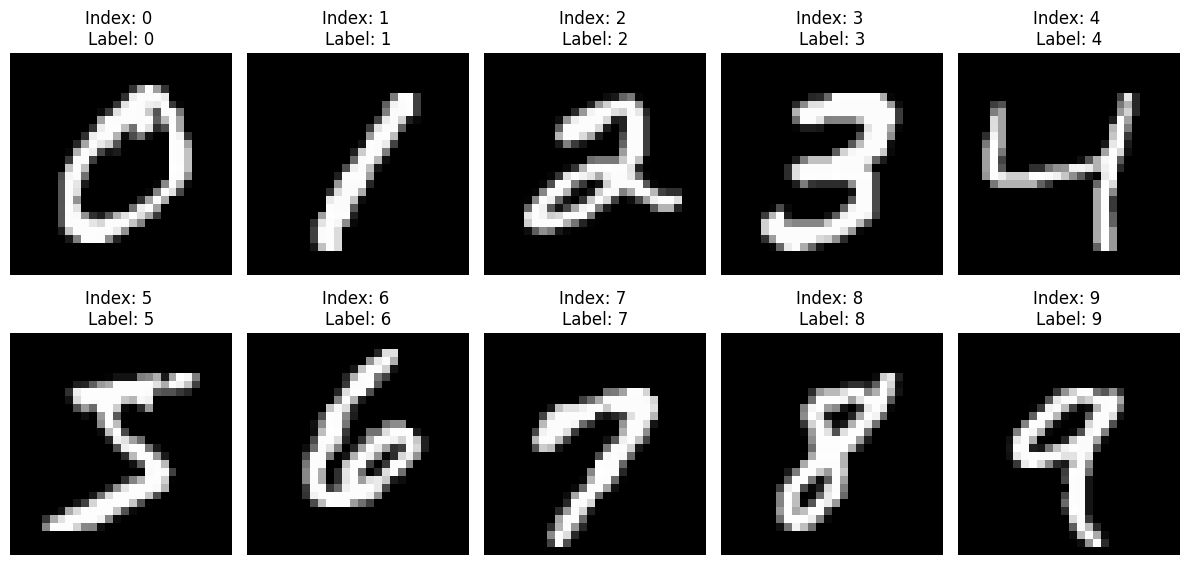

255


In [56]:
plot_image_index(list_labels, images, labels, 10)
print(np.max(images))

In [57]:
X_raw = np.array(images, dtype=float)
Y = np.array(labels)

print("Đã tải thành công tập dữ liệu huấn luyện!")
print("Kích thước mảng ảnh thô:", X_raw.shape)
images, labels = mndata.load_training()



Đã tải thành công tập dữ liệu huấn luyện!
Kích thước mảng ảnh thô: (60000, 784)


In [58]:
# Giảm chiều ma trận
X_flatten = X_raw.reshape(X_raw.shape[0], -1)

# Chuẩn hóa dữ liệu
from sklearn.preprocessing import normalize
X = normalize(X_flatten, norm='l2')
print(type(X))
print(type(Y))
print(X.shape)
print(Y.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(60000, 784)
(60000,)


In [59]:
def label_to_onehot(Y):
    K = max(Y) + 1
    N = len(Y)
    result = np.zeros((N,K))
    for i in range(len(Y)):
        result[i][Y[i]] = 1
    return result

Y = label_to_onehot(Y)
print(Y)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [60]:
def relu(z): 
    return np.maximum(0,z)

def softmax(z):
    return np.exp(z)/np.sum(np.exp(z),axis=0, keepdims=True) 

In [61]:
d = [784, 512, 128, 32, 10]
def feed_forward(X, W, b, d):
    """
    input:
    X: features (784,N)
    W: tập hợp L m trận
    L1 = 512, L2 = 128, L3 = 32, L4 = 10
    f2 = ReLu, f3 = ReLU, f4 = ReLu, f5 = Softmax
    """
    A = []
    Z = []
    a = X
    A.append(a)
    z = np.dot(W[0].T,a) + b[0]
    Z.append(z)
    for layer in range(1, len(d)-1):
        a = relu(z)
        A.append(a)
        z = np.dot(W[layer].T,a) + b[layer]
        Z.append(z)
    a_L = softmax(z)
    A.append(a_L)
    return a_L, A, Z

W = [
    np.random.uniform(0, 0.1, size=(784,512)),
    np.random.uniform(0, 0.1, size=(512,128)),
    np.random.uniform(0, 0.1, size=(128,32)),
    np.random.uniform(0, 0.1, size=(32,10)),
    ]

b = [np.zeros((d[i+1], 1)) for i in range(len(d)-1)]
y_hat, A, Z = feed_forward(X.T, W, b, [784, 512, 128, 32, 10])
print(y_hat.shape)
print(W)

(10, 60000)
[array([[0.0782574 , 0.0196415 , 0.05618135, ..., 0.01708469, 0.01526975,
        0.09010319],
       [0.04061198, 0.06876533, 0.05703417, ..., 0.07429967, 0.0153985 ,
        0.02119909],
       [0.02399397, 0.05011019, 0.09587886, ..., 0.09973726, 0.08348248,
        0.07270332],
       ...,
       [0.05511451, 0.06071745, 0.08272373, ..., 0.01070397, 0.06347969,
        0.03891172],
       [0.08677518, 0.04406972, 0.08937662, ..., 0.04924967, 0.0401229 ,
        0.08165325],
       [0.01109461, 0.06223842, 0.08501541, ..., 0.07128759, 0.04898415,
        0.05354005]], shape=(784, 512)), array([[0.04661891, 0.06689527, 0.07604633, ..., 0.086288  , 0.06423326,
        0.00987173],
       [0.05933931, 0.03984769, 0.04605996, ..., 0.00693293, 0.09219226,
        0.03574557],
       [0.0140809 , 0.08768493, 0.0765857 , ..., 0.05344133, 0.05624026,
        0.09839578],
       ...,
       [0.01564621, 0.04876288, 0.02074755, ..., 0.0800547 , 0.02340332,
        0.08765625],
   

In [62]:
def calculate_loss(y, y_hat, epsilon=1e-10):
    N = y.shape[1]
    return -np.sum(y * np.log(y_hat + epsilon)) / N
print(Y.shape)
J = calculate_loss(Y.T, y_hat, epsilon=1e-10)
print(J)

(60000, 10)
16.484651830314444


In [63]:
def backpropagation(W, A, y, Z):
    """
    input: w, A, b 
    - W: list(4 matrix)
    - A: list(4 vector)
    - b: list(4 vector bias)
    Output: gradient_w list (đạo hàm của J theo W từng layer)
            gradient_b list (đạo hàm của J theo b từng layer)

        dJ/dW_L = a_L-1 . (a_L - y)
        dJ/dB_L = a_L-y
        e_l = (W_l+1.e_l+1) * f'(z_l)
        dJ/dW_l = a_l-1 . e_l.T
        dJ/db_l = e_l
        
    """
    gradient_W = []
    gradient_b = []
    e_l = (A[-1] - y)/y.shape[1] # Kết quả của hàm softmax, chia N để nhất quán với loss\
    for l in range(len(W)-1, -1, -1):
        gradient_W.append(np.dot(A[l], e_l.T))
        gradient_b.append(np.sum(e_l, axis=1, keepdims=True))


        if l > 0:
            e_l = np.dot(W[l], e_l) * (Z[l-1] > 0)
            # e_3 = (W_4 * e_4) * f'(z_3)     (đạo hàm của ReLU)
    gradient_W.reverse()
    gradient_b.reverse()
    return gradient_W, gradient_b

gradient_W, gradient_b = backpropagation(W, A, Y.T, Z)
print(gradient_W)

[array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(784, 512)), array([[0.00512227, 0.00668347, 0.01220755, ..., 0.00641938, 0.00339028,
        0.00852959],
       [0.00485162, 0.00633564, 0.01160348, ..., 0.0060741 , 0.00322341,
        0.00809041],
       [0.00490367, 0.00639633, 0.01166216, ..., 0.00613337, 0.00325918,
        0.00815794],
       ...,
       [0.00498282, 0.0064835 , 0.01181702, ..., 0.00622863, 0.00328877,
        0.00827185],
       [0.00500378, 0.00650238, 0.01187041, ..., 0.0062531 , 0.00328642,
        0.00830702],
       [0.00504296, 0.00652361, 0.01195621, ..., 0.00627807, 0.00331678,
        0.00838324]], shape=(512, 128)), array([[ 0.2439157 ,  0.57384461, -0.07313038, ..., -0.19882545,
         0.08645214, -0.42357423],
       [ 0.2351212 ,  0.5532115 , -0.070583

In [64]:
def gradient_descent(W, b, gradient_W, gradient_b, eta=0.001):
    for l in range(len(W)):
        W[l] -= eta * gradient_W[l]
        b[l] -= eta * gradient_b[l]
    return W, b

print(gradient_descent(W, b, gradient_W, gradient_b, eta=0.001))

([array([[0.0782574 , 0.0196415 , 0.05618135, ..., 0.01708469, 0.01526975,
        0.09010319],
       [0.04061198, 0.06876533, 0.05703417, ..., 0.07429967, 0.0153985 ,
        0.02119909],
       [0.02399397, 0.05011019, 0.09587886, ..., 0.09973726, 0.08348248,
        0.07270332],
       ...,
       [0.05511451, 0.06071745, 0.08272373, ..., 0.01070397, 0.06347969,
        0.03891172],
       [0.08677518, 0.04406972, 0.08937662, ..., 0.04924967, 0.0401229 ,
        0.08165325],
       [0.01109461, 0.06223842, 0.08501541, ..., 0.07128759, 0.04898415,
        0.05354005]], shape=(784, 512)), array([[0.04661379, 0.06688858, 0.07603412, ..., 0.08628158, 0.06422987,
        0.0098632 ],
       [0.05933446, 0.03984136, 0.04604835, ..., 0.00692686, 0.09218904,
        0.03573748],
       [0.01407599, 0.08767853, 0.07657404, ..., 0.0534352 , 0.056237  ,
        0.09838763],
       ...,
       [0.01564123, 0.04875639, 0.02073573, ..., 0.08004847, 0.02340003,
        0.08764798],
       [0.0895

In [65]:
print(X.shape)
print(Y.shape)

(60000, 784)
(60000, 10)


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.985, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.985, random_state=42)
X_train, X_val, X_test = X_train.T, X_val.T, X_test.T
y_train, y_val, y_test = y_train.T, y_val.T, y_test.T

In [67]:
print(y_train.shape)
print(X_train.shape)

(10, 900)
(784, 900)


In [68]:
"""
feed_forward = predict
pred cho ra 0/1
pred_proba cho ra xác suất từng nhãn
"""
def predict(X, W, b, d):
    y_hat, _, _ = feed_forward(X, W, b, d)
    index = np.argmax(y_hat, axis=0)
    return np.eye(y_hat.shape[0])[index].T

print(predict(X.T, W, b, d))

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [69]:
def accuracy(y_hat, Y):
    accuracy = np.mean(y_hat == Y)*100
    return (f"Accuracy: {accuracy:.2f}%")

print(accuracy(y_hat,Y.T))

Accuracy: 0.00%


In [71]:
def train(X_train, y_train, W, b, eta=0.01, epochs=5, d = [784, 512, 128, 32, 10]):
    """
    Input:
    - X: feature (784*N)
    - Y: Label (N*10)
    - W: list vector
    - b: list vector bias
    - d: number of layers 
    - learning rate
    - epochs

    -Output: 
    - W: list vector
    - b: list vector bias
    """
    for epoch in range(epochs):
        X_train, y_train = shuffle(X_train.T,y_train.T) # sklearn trộn theo hàng, nên phải Transfer
        X_train = X_train.T
        y_train = y_train.T
        for i in range(X_train.shape[1]):
            y_hat, A, Z = feed_forward(X_train, W, b,d)
            g_W, g_b = backpropagation(W, A, y_train, Z)
            W,b = gradient_descent(W, b, g_W, g_b, eta)
        print(f"Epoch {epoch+1},","loss:",calculate_loss(y_train, y_hat, epsilon=1e-10))

        Y_hat = predict(X.T,W,b,d)
        # Y_hat_val = predict(X_val, W)
        # So sánh với Y (vì đã shuffle theo X)
        # predict thay vì predict_proba
        # print(f"Loss on validation: {calculate_loss(X_val,y_val,W)}")
        print("Accuracy on train", accuracy(Y_hat, Y.T))
        # print("Accuracy on validation: ",accuracy(Y_hat_val, y_val))


    return W, b


W, b = train(X_train, y_train, W, b, eta=0.01, epochs=10)

Epoch 1, loss: 2.298718056457523
Accuracy on train Accuracy: 82.25%
Epoch 2, loss: 2.2986298515878967
Accuracy on train Accuracy: 82.25%
Epoch 3, loss: 2.2986152281706453
Accuracy on train Accuracy: 82.25%
Epoch 4, loss: 2.29861271761715
Accuracy on train Accuracy: 82.25%
Epoch 5, loss: 2.2986122725322002
Accuracy on train Accuracy: 82.25%


KeyboardInterrupt: 

In [ ]:
def onehot_to_label(Y):
    label = []
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]): 
            if Y[i,j] == 1:
                label.append(j)
    return np.array(label)

label_after_predict = onehot_to_label(Y)
print(label_after_predict)
print(M)

[5 0 4 ... 5 6 8]


NameError: name 'M' is not defined